## Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

from prophet import Prophet
from neuralprophet import NeuralProphet
import optuna
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# Verify cuda is a available
import torch

print(torch.__version__)
print(torch.cuda.is_available())      # Should be True
# print(torch.cuda.get_device_name(0))  # Should show your GPU name

2.5.1+cu121
True


## Visualization Setup

In [3]:
font_path = '/usr/share/fonts/noto_sans_mono/NotoSansMono_SemiCondensed-SemiBold.ttf'
font_prop = fm.FontProperties(fname=font_path)

sns.set_theme(
    style='darkgrid',
    context='notebook',
    font=font_prop.get_name(),
    rc={
        'font.weight': 'semibold',
        'axes.labelweight': 'semibold',
        'axes.titlesize': 'large',
        'axes.titleweight': 'semibold',
        'axes.labelsize': 'medium',
        }
    )

## Load Data

In [4]:
pjmw_df = pd.read_csv('data/PJMW_hourly.csv')

In [5]:
pjmw_df.shape

(143206, 2)

In [6]:
pjmw_df.isna().sum()

Datetime    0
PJMW_MW     0
dtype: int64

In [7]:
pjmw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  143206 non-null  object 
 1   PJMW_MW   143206 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [8]:
pjmw_df.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077.0
1,2002-12-31 02:00:00,4939.0
2,2002-12-31 03:00:00,4885.0
3,2002-12-31 04:00:00,4857.0
4,2002-12-31 05:00:00,4930.0


In [9]:
pjmw_df.rename(columns={'Datetime': 'datetime', 'PJMW_MW': 'mw'}, inplace=True)

In [10]:
pjmw_df['datetime'] = pd.to_datetime(pjmw_df['datetime'])
pjmw_df['year'] = pjmw_df['datetime'].dt.year
pjmw_df['month'] = pjmw_df['datetime'].dt.month
pjmw_df['day'] = pjmw_df['datetime'].dt.day
pjmw_df['hour'] = pjmw_df['datetime'].dt.hour
pjmw_df['day_of_week'] = pjmw_df['datetime'].dt.dayofweek
pjmw_df['day_of_year'] = pjmw_df['datetime'].dt.dayofyear
pjmw_df['week_of_year'] = pjmw_df['datetime'].dt.isocalendar().week
pjmw_df['quarter'] = pjmw_df['datetime'].dt.quarter

## EDA

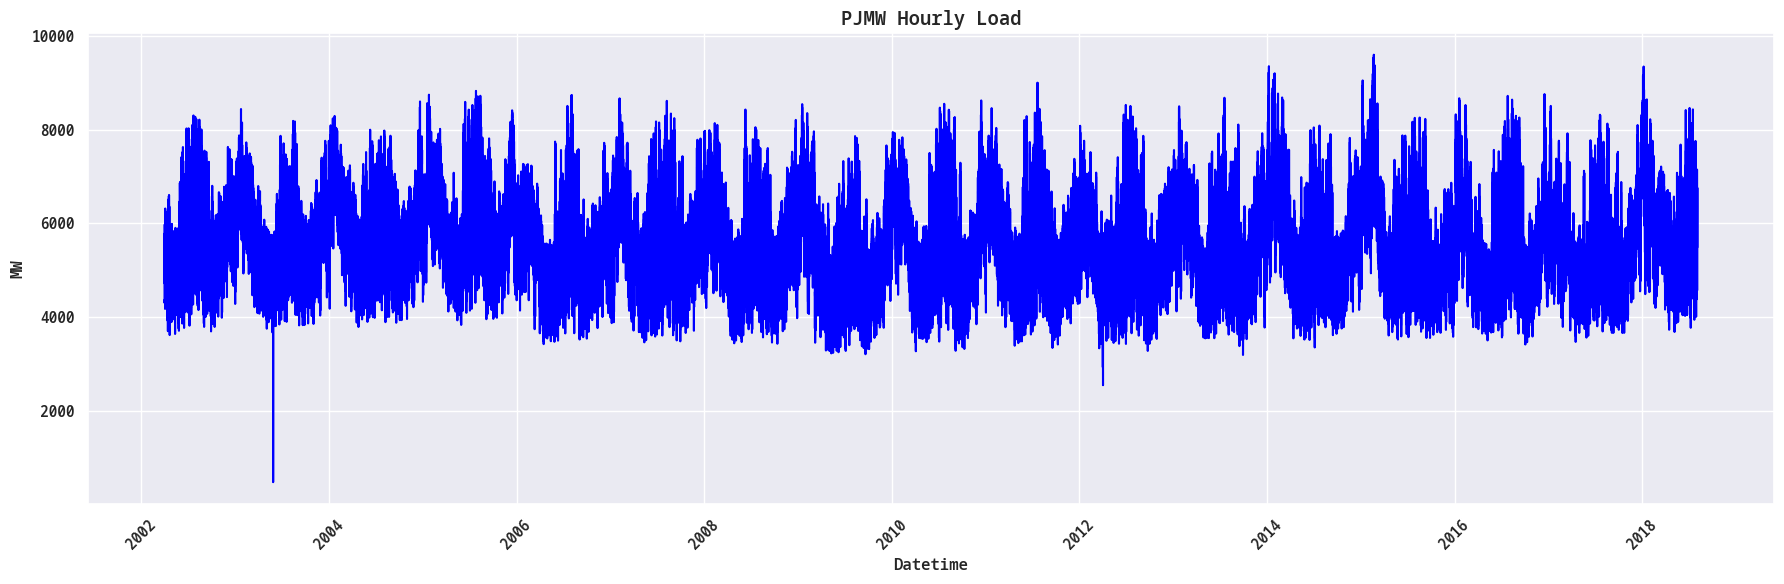

<IPython.core.display.Javascript object>

In [11]:
fig, ax = plt.subplots(figsize=(18, 6))

sns.lineplot(
        data=pjmw_df,
        x='datetime',
        y='mw',
        ax=ax,
        color='blue',
        linewidth=1.5
        )

ax.set_title('PJMW Hourly Load')
ax.set_xlabel('Datetime')
ax.set_ylabel('MW')
ax.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
pjmw_df.head()

,datetime,mw,year,month,day,hour,day_of_week,day_of_year,week_of_year,quarter
0,2002-12-31 01:00:00,5077.0,2002,12,31,1,1,365,1,4
1,2002-12-31 02:00:00,4939.0,2002,12,31,2,1,365,1,4
2,2002-12-31 03:00:00,4885.0,2002,12,31,3,1,365,1,4
3,2002-12-31 04:00:00,4857.0,2002,12,31,4,1,365,1,4
4,2002-12-31 05:00:00,4930.0,2002,12,31,5,1,365,1,4


Let's see how each of the time features correlates with the load (MW).

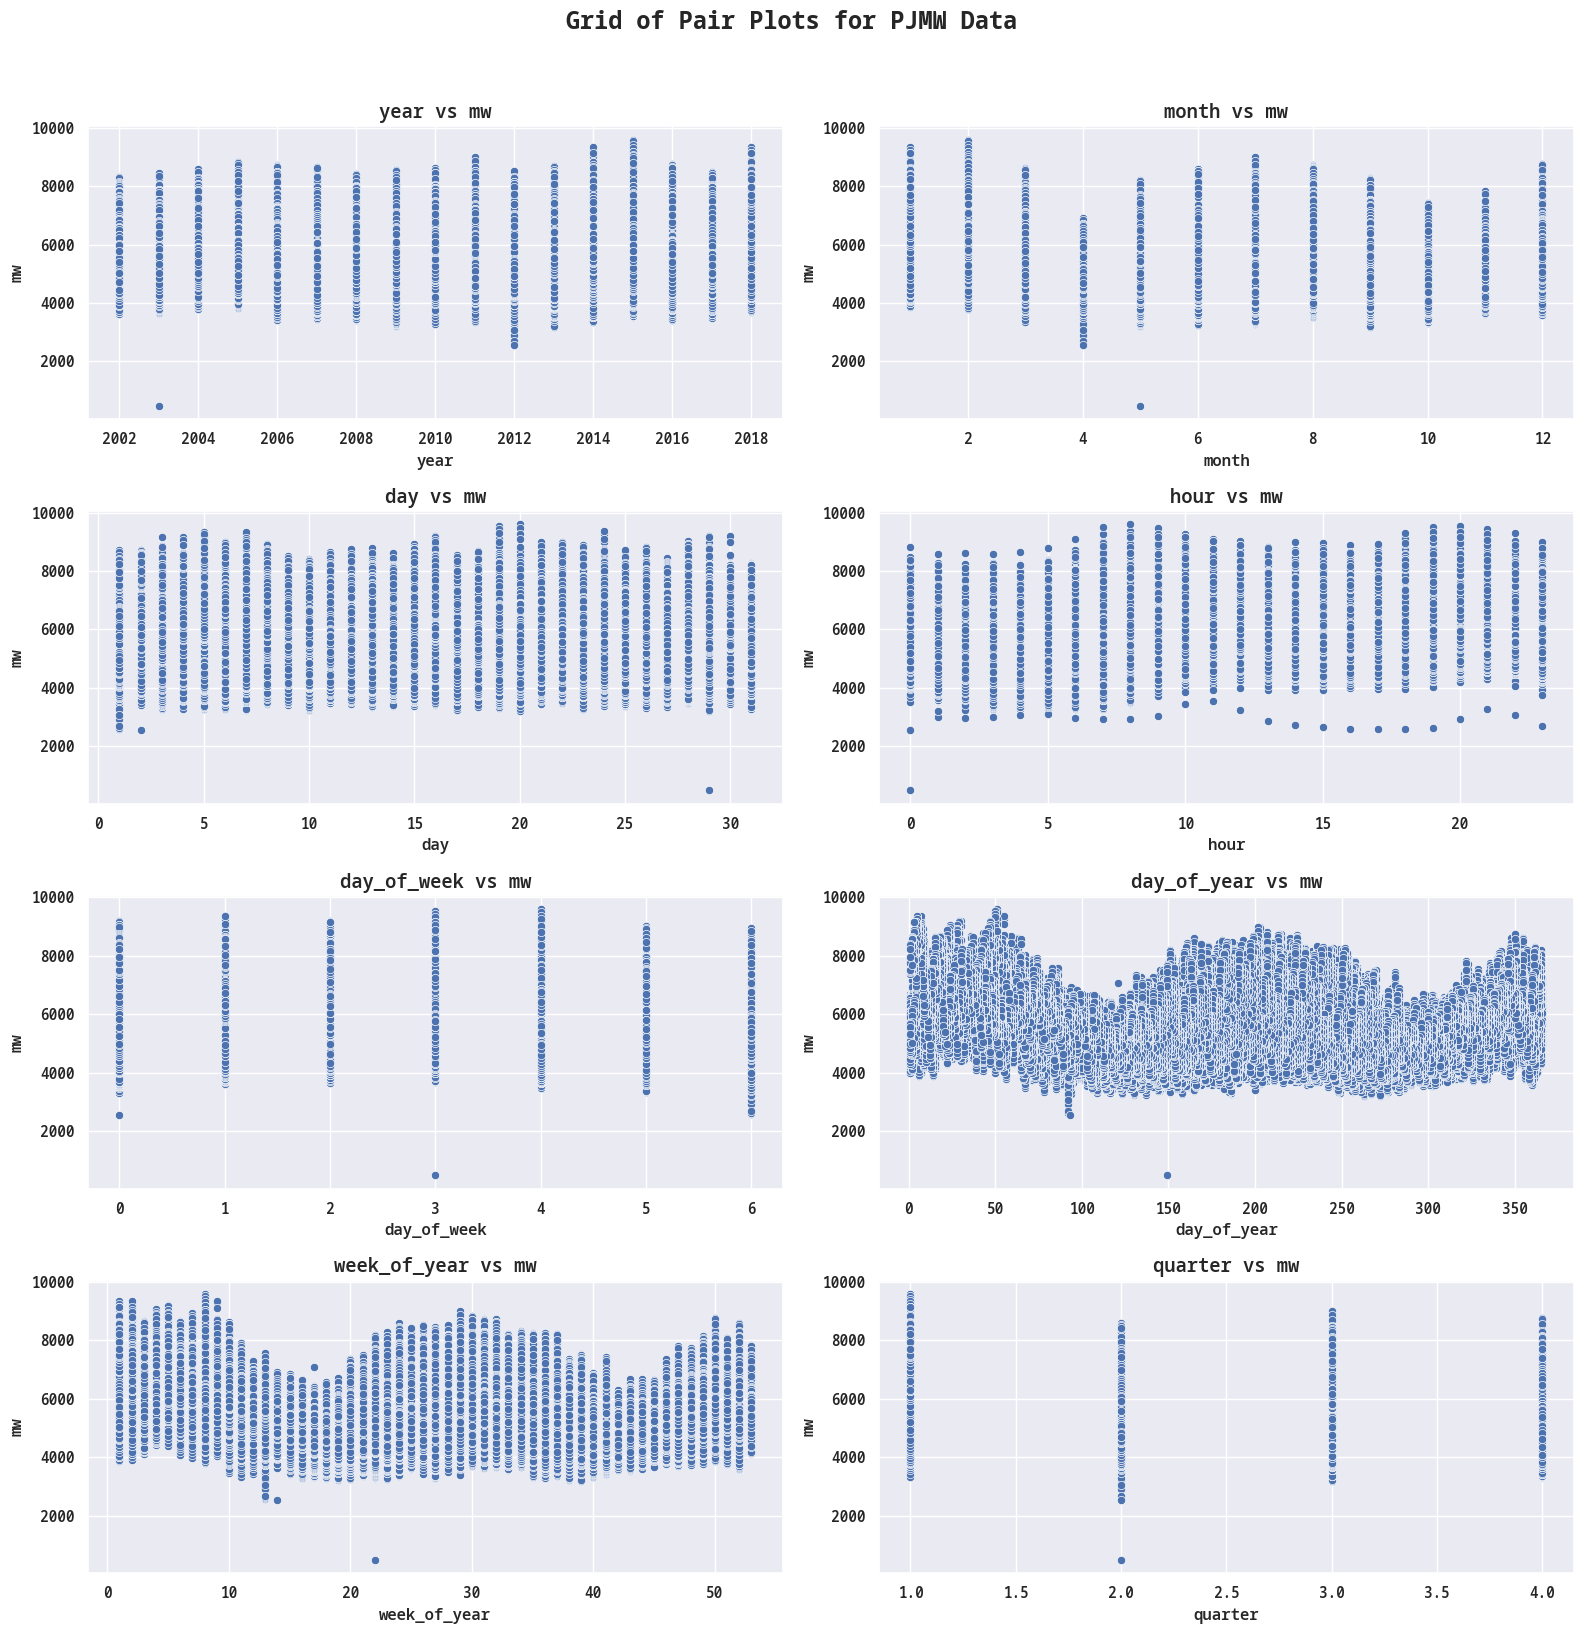

In [13]:
x_vars = [
    'year',
    'month',
    'day',
    'hour',
    'day_of_week',
    'day_of_year',
    'week_of_year',
    'quarter'
]

fig, axes = plt.subplots(4, 2, figsize=(16, 16))  # 4 rows, 2 columns
axes = axes.flatten()

for i, var in enumerate(x_vars):
    sns.scatterplot(data=pjmw_df, x=var, y='mw', ax=axes[i])
    axes[i].set_title(f'{var} vs mw')

plt.suptitle('Grid of Pair Plots for PJMW Data', fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
train_val_test_df = pjmw_df.copy()[['datetime', 'mw']]. \
        rename(columns={'datetime': 'ds', 'mw': 'y'}). \
        sort_values(by='ds'). \
        reset_index(drop=True)

train_val_test_df.head()

,ds,y
0,2002-04-01 01:00:00,4374.0
1,2002-04-01 02:00:00,4306.0
2,2002-04-01 03:00:00,4322.0
3,2002-04-01 04:00:00,4359.0
4,2002-04-01 05:00:00,4436.0


In [15]:
train_val_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   ds      143206 non-null  datetime64[ns]
 1   y       143206 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.2 MB


In [16]:
total_days = (train_val_test_df['ds'].max() - train_val_test_df['ds'].min()).days

train_days = int(0.7 * total_days)
val_days   = int(0.15 * total_days)
test_days  = total_days - train_days - val_days

train_end = train_val_test_df['ds'].min() + pd.Timedelta(days=train_days)
val_end   = train_end + pd.Timedelta(days=val_days)

train_df = train_val_test_df[train_val_test_df['ds'] <= train_end]
val_df   = train_val_test_df[(train_val_test_df['ds'] > train_end) & (train_val_test_df['ds'] <= val_end)]
test_df  = train_val_test_df[train_val_test_df['ds'] > val_end]

In [17]:
# print size, min and max dates of each set
print(f"Train set:      {train_df.shape}, {train_df['ds'].min()} - {train_df['ds'].max()}")
print(f"Validation set: {val_df.shape}, {val_df['ds'].min()} - {val_df['ds'].max()}")
print(f"Test set:       {test_df.shape}, {test_df['ds'].min()} - {test_df['ds'].max()}")

Train set:      (100201, 2), 2002-04-01 01:00:00 - 2013-09-06 01:00:00
Validation set: (21479, 2), 2013-09-06 02:00:00 - 2016-02-18 01:00:00
Test set:       (21526, 2), 2016-02-18 02:00:00 - 2018-08-03 00:00:00


In [18]:
# print the number of NAs in each set

print(f"Train set NAs:      {train_df.isna().sum().sum()}")
print(f"Validation set NAs: {val_df.isna().sum().sum()}")
print(f"Test set NAs:       {test_df.isna().sum().sum()}")

Train set NAs:      0
Validation set NAs: 0
Test set NAs:       0


In [24]:
def objective_prophet(trial):
    params = {
        "changepoint_prior_scale": trial.suggest_float("changepoint_prior_scale", 0.001, 0.5, log=True),
        "seasonality_prior_scale": trial.suggest_float("seasonality_prior_scale", 0.01, 10.0, log=True),
        "holidays_prior_scale":    trial.suggest_float("holidays_prior_scale", 0.01, 10.0, log=True),
        "seasonality_mode":        trial.suggest_categorical("seasonality_mode", ["additive", "multiplicative"]),
        "changepoint_range":       trial.suggest_float("changepoint_range", 0.8, 0.95),
    }

    model = Prophet(**params)
    model.fit(train_df)

    # Forecast on validation
    future_df = model.make_future_dataframe(periods=len(val_df), freq='H')
    forecast_df = model.predict(future_df.tail(len(val_df)))

    # Match forecast to actuals
    y_pred = forecast_df['yhat'].values
    y_true = val_df['y'].values

    return mean_absolute_error(y_true, y_pred)

In [25]:
%%time

study = optuna.create_study(direction="minimize")
study.optimize(objective_prophet, n_trials=50, timeout=600, n_jobs=4)
best_prophet_params = study.best_params.copy()

print("Best parameters:", study.best_params)
print("Best validation MAE:", study.best_value)

[I 2025-06-15 19:24:42,097] A new study created in memory with name: no-name-225c4e5a-c3b8-4369-8f8f-f89ba14a20e8
19:25:03 - cmdstanpy - INFO - Chain [1] start processing
19:25:04 - cmdstanpy - INFO - Chain [1] start processing
19:25:05 - cmdstanpy - INFO - Chain [1] start processing
19:25:05 - cmdstanpy - INFO - Chain [1] start processing
19:28:48 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-06-15 19:28:56,963] Trial 2 finished with value: 568.1984677561777 and parameters: {'changepoint_prior_scale': 0.015601376420329785, 'seasonality_prior_scale': 3.2997295716160484, 'holidays_prior_scale': 0.01295575159195977, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.9415933161552006}. Best is trial 2 with value: 568.1984677561777.
19:29:00 - cmdstanpy - INFO - Chain [1] done processing
19:29:06 - cmdstanpy - INFO - Chain [1] start processing
[I 2025-06-15 19:29:08,906] Trial 0 finished with value: 575.3682981002095 and parameters: {'changepoint_prior_scale': 0.00986685

Best parameters: {'changepoint_prior_scale': 0.1182410545802119, 'seasonality_prior_scale': 0.29624468123369724, 'holidays_prior_scale': 0.4104795394233475, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.9167473106794491}
Best validation MAE: 565.2938922407038
CPU times: user 3min 33s, sys: 38.5 s, total: 4min 11s
Wall time: 13min 11s


<IPython.core.display.Javascript object>

In [26]:
best_prophet_model = Prophet(**best_prophet_params)
best_prophet_model.fit(train_df)

19:37:59 - cmdstanpy - INFO - Chain [1] start processing
19:39:29 - cmdstanpy - INFO - Chain [1] done processing


<IPython.core.display.Javascript object>

In [27]:
def evaluate_model(model, train_df, val_df, test_df):
    # Forecast on validation
    future_df = model.make_future_dataframe(periods=len(val_df), freq='D')
    forecast_df = model.predict(future_df.tail(len(val_df)))

    # Match forecast to actuals
    y_pred_val = forecast_df['yhat'].values
    y_true_val = val_df['y'].values

    val_mae = mean_absolute_error(y_true_val, y_pred_val)

    # Forecast on test data
    future_test_df = model.make_future_dataframe(periods=len(test_df), freq='D')
    forecast_test_df = model.predict(future_test_df.tail(len(test_df)))

    y_pred_test = forecast_test_df['yhat'].values
    y_true_test = test_df['y'].values

    test_mae = mean_absolute_error(y_true_test, y_pred_test)

    return val_mae, test_mae, y_pred_val, y_true_val, y_pred_test, y_true_test

def plot_results(y_true_val, y_pred_val, y_true_test, y_pred_test):
    plt.figure(figsize=(14, 7))

    # Validation set
    plt.subplot(1, 2, 1)
    plt.plot(y_true_val, label='Actual (Validation)', color='blue', alpha=0.7)
    plt.plot(y_pred_val, label='Predicted (Validation)', color='orange', linestyle='--', alpha=0.7)
    plt.title('Validation Set Predictions')
    plt.xlabel('Time')
    plt.ylabel('MW')
    plt.legend()
    plt.grid(True)

    # Test set
    plt.subplot(1, 2, 2)
    plt.plot(y_true_test, label='Actual (Test)', color='blue', alpha=0.7)
    plt.plot(y_pred_test, label='Predicted (Test)', color='orange', linestyle='--', alpha=0.7)
    plt.title('Test Set Predictions')
    plt.xlabel('Time')
    plt.ylabel('MW')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Validation MAE: 1150.4340
Test MAE: 1062.1630


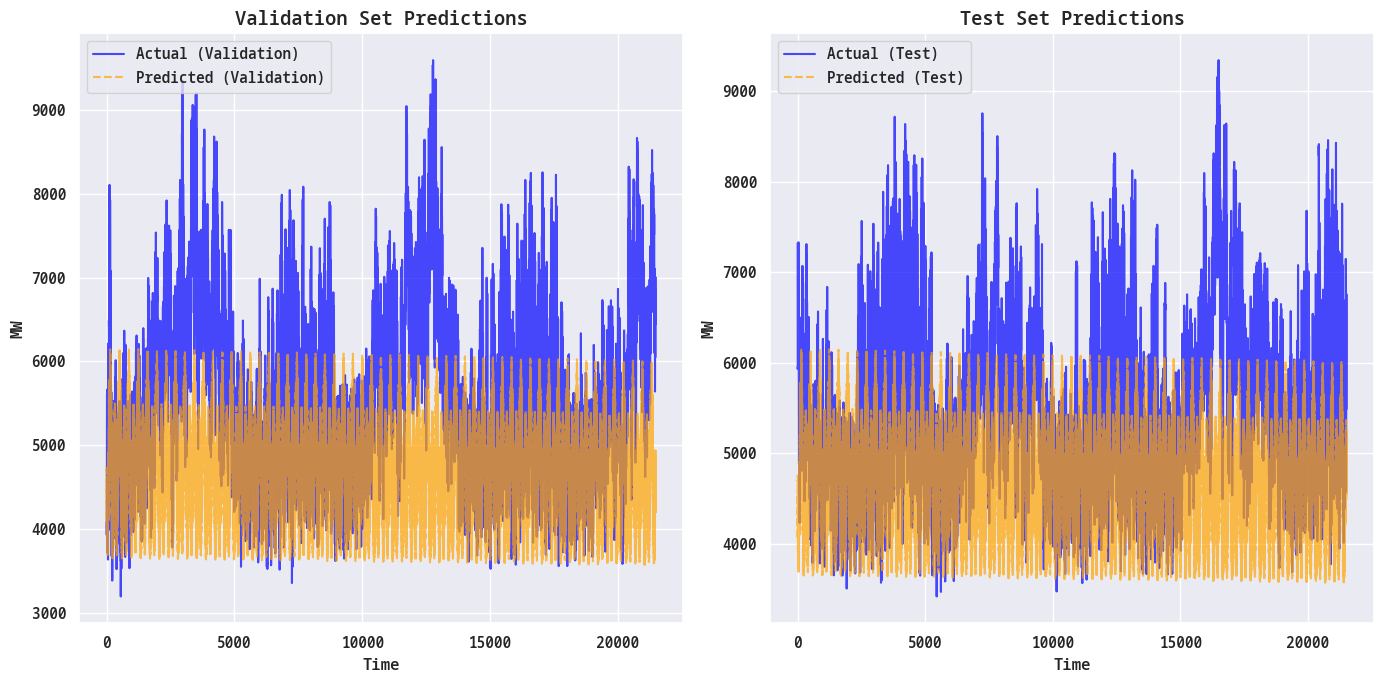

In [28]:
val_mae, test_mae, y_pred_val, y_true_val, y_pred_test, y_true_test = evaluate_model(
    best_prophet_model, train_df, val_df, test_df
)

print(f"Validation MAE: {val_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")

# Plot results
plot_results(y_true_val, y_pred_val, y_true_test, y_pred_test)

In [90]:
def objective_neural_prophet(trial):
    # Define hyperparameters to optimize
    params = {
        'n_lags': trial.suggest_int('n_lags', 5, 30),
        'n_forecasts': trial.suggest_int('n_forecasts', 1, 7),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
        'epochs': trial.suggest_int('epochs', 50, 150),
        'batch_size': trial.suggest_categorical('batch_size', [512, 1024, 2048]),
        'loss_func': trial.suggest_categorical('loss_func', ['Huber', 'MAE', 'MSE']),
    }

    try:
        # Create and train model
        model = NeuralProphet(
            n_lags=params['n_lags'],
            n_forecasts=params['n_forecasts'],
            learning_rate=params['learning_rate'],
            epochs=params['epochs'],
            batch_size=params['batch_size'],
            loss_func=params['loss_func'],
            collect_metrics=False
        )

        # Fit model on training data
        model.fit(train_df, freq='H')

        # Make predictions on val data
        future = model.make_future_dataframe(
            train_df,
            periods=len(val_df),
            n_historic_predictions=True
        )
        forecast = model.predict(future)

        # Extract val predictions
        val_pred = forecast.tail(len(val_df))['yhat1'].values
        val_actual = val_df['y'].values

        # Calculate and return MAE
        mae = mean_absolute_error(val_actual, val_pred)
        return mae

    except Exception as e:
        # Return high error for failed trials
        print(f"Trial failed: {e}")
        return float('inf')

In [94]:
def check_train_val_gap(train_df, val_df):
    last_train = train_df['ds'].max()
    first_val = val_df['ds'].min()
    gap_days = (first_val - last_train).days

    print(f"Last training date: {last_train}")
    print(f"First validation date: {first_val}")
    print(f"Gap between train and val: {gap_days} days")

    if gap_days != 1:
        print(f"⚠️  WARNING: Expected 1 day gap, found {gap_days} days")
        return False
    else:
        print("✅ No gap detected")
        return True

# Check your data
check_train_val_gap(train_df, val_df)

Last training date: 2013-09-06 01:00:00
First validation date: 2013-09-06 02:00:00
Gap between train and val: 0 days
⚠️  WARNING: Expected 1 day gap, found 0 days


False

In [95]:
test_model = NeuralProphet()
test_model.fit(train_df, freq='D')

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.975% of the data.
WARNING - (NP.df_utils._infer_frequency) - Defined frequency D is different than major frequency H
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 256
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 30


Training: |                                                                                                   …

Finding best initial lr:   0%|          | 0/275 [00:00<?, ?it/s]

Training: |                                                                                                   …

NameError: name 'exit' is not defined

<IPython.core.display.Javascript object>

In [91]:
%%time
study = optuna.create_study(direction="minimize")
study.optimize(objective_neural_prophet, n_trials=50, timeout=600)

print("Best parameters for NeuralProphet:", study.best_params)
print("Best validation MAE for NeuralProphet:", study.best_value)

[I 2025-06-15 18:42:22,550] A new study created in memory with name: no-name-b1756d57-b52d-4cba-9b20-59499a154d14
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.975% of the data.
WARNING - (NP.df_utils._infer_frequency) - Defined frequency D is different than major frequency H
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.


Training: |                                                                                                   …

Training: |                                                                                                   …

INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.975% of the data.
WARNING - (NP.df_utils._infer_frequency) - Defined frequency D is different than major frequency H
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 7.
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.968% of the data.
WARNING - (NP.df_utils._infer_frequency) - Defined frequency D is different than major frequency H
INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.968% of the data.
WARNING - (NP.df_utils._infer_frequency) - Defined frequency D is different than major frequency H
INFO - (NP.data.processing._handle_missing_data) - Dropped 7 rows at the end with NaNs in 'y' column.


Predicting: |                                                                                                 …

...

Training: |                                                                                                   …

2025-06-15T18:52:32.325141+0300 - Timed out waiting for syncing to complete.


[I 2025-06-15 18:52:37,048] Trial 2 finished with value: inf and parameters: {'n_lags': 22, 'n_forecasts': 3, 'learning_rate': 0.00041618301590195004, 'epochs': 50, 'batch_size': 2048, 'loss_func': 'MAE'}. Best is trial 0 with value: inf.


Trial failed: name 'exit' is not defined
Best parameters for NeuralProphet: {'n_lags': 13, 'n_forecasts': 7, 'learning_rate': 0.0008417925260870776, 'epochs': 122, 'batch_size': 2048, 'loss_func': 'MAE'}
Best validation MAE for NeuralProphet: inf
CPU times: user 17min 51s, sys: 1min 38s, total: 19min 29s
Wall time: 10min 14s


<IPython.core.display.Javascript object>

In [ ]:
best_model = NeuralProphet(
    n_lags=study.best_params['n_lags'],
    n_forecasts=study.best_params['n_forecasts'],
    learning_rate=study.best_params['learning_rate'],
    epochs=study.best_params['epochs'],
    batch_size=study.best_params['batch_size'],
    d_hidden=study.best_params['d_hidden'],
    loss_func=study.best_params['loss_func']
)

best_model.fit(train_data, freq='D')

# Final evaluation
future = best_model.make_future_dataframe(
    train_data,
    periods=len(test_data),
    n_historic_predictions=True
)
final_forecast = best_model.predict(future)

final_pred = final_forecast.tail(len(test_data))['yhat1'].values
final_mae = mean_absolute_error(test_data['y'].values, final_pred)

print(f"Final model MAE: {final_mae:.4f}")

In [ ]:
# Optional: Plot results
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))
    plt.plot(test_data['y'].values, label='Actual', alpha=0.7)
    plt.plot(final_pred, label='Predicted', alpha=0.7)
    plt.title('NeuralProphet Predictions (Optimized)')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

except ImportError:
    print("Matplotlib not available for plotting")

# Show parameter importance
print("\nParameter Importance:")
importance = optuna.importance.get_param_importances(study)
for param, imp in sorted(importance.items(), key=lambda x: x[1], reverse=True):
    print(f"{param}: {imp:.3f}")